# 📝 Exercise M7.01

In this exercise we will define dummy classification baselines and use them as
reference to assess the relative predictive performance of a given model of
interest.

We illustrate those baselines with the help of the Adult Census dataset, using
only the numerical features for the sake of simplicity.

In [1]:
import pandas as pd

adult_census = pd.read_csv("../datasets/adult-census-numeric-all.csv")
data, target = adult_census.drop(columns="class"), adult_census["class"]

First, define a `ShuffleSplit` cross-validation strategy taking half of the
samples as a testing at each round. Let us use 10 cross-validation rounds.

In [2]:
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=10, test_size=0.5)

Next, create a machine learning pipeline composed of a transformer to
standardize the data followed by a logistic regression classifier.

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

Compute the cross-validation (test) scores for the classifier on this dataset.
Store the results pandas Series as we did in the previous notebook.

In [4]:
from sklearn.model_selection import cross_validate

cv_results_model = cross_validate(
    model,
    data,
    target
)

In [5]:
cv_scores_model = pd.Series(cv_results_model['test_score'], name="cv_scores_model")

Now, compute the cross-validation scores of a dummy classifier that constantly
predicts the most frequent class observed the training set. Please refer to
the online documentation for the [sklearn.dummy.DummyClassifier
](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)
class.

Store the results in a second pandas Series.

In [6]:
from sklearn.dummy import DummyClassifier

cv_results_dummy = cross_validate(
    DummyClassifier(strategy="most_frequent"),
    data,
    target
)

In [7]:
cv_scores_dummy = pd.Series(cv_results_dummy['test_score'], name="cv_scores_dummy")

Now that we collected the results from the baseline and the model, concatenate
the test scores as columns a single pandas dataframe.

In [8]:
cv_scores = pd.concat(
    [cv_scores_model, cv_scores_dummy],
    axis=1
)

cv_scores

,cv_scores_model,cv_scores_dummy
0,0.812263,0.760672
1,0.809602,0.760672
2,0.813370,0.760749
3,0.813370,0.760749
4,0.822174,0.760749



Next, plot the histogram of the cross-validation test scores for both models
with the help of [pandas built-in plotting
function](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html#histograms).

What conclusions do you draw from the results?

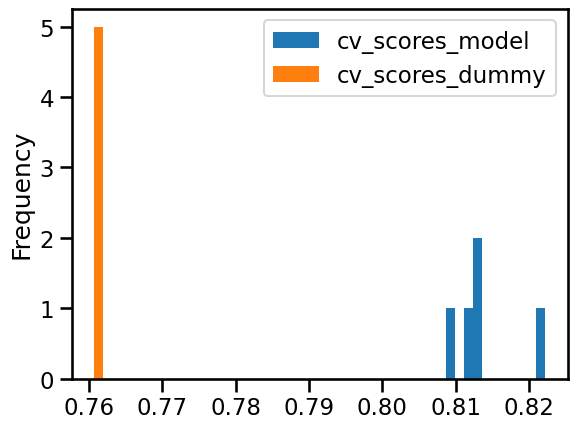

In [9]:
import matplotlib.pyplot as plt

_ = cv_scores.plot.hist(bins=50)

-> We observe that the tree has a better score than a dummy classifier with a most frequent strat.

Change the `strategy` of the dummy classifier to `"stratified"`, compute the
results. Similarly compute scores for `strategy="uniform"` and then the  plot
the distribution together with the other results.

Are those new baselines better than the previous one? Why is this the case?

Please refer to the scikit-learn documentation on
[sklearn.dummy.DummyClassifier](
https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)
to find out about the meaning of the `"stratified"` and `"uniform"`
strategies.

In [10]:
cv_results_dummy_stratified = cross_validate(
    DummyClassifier(strategy="stratified"),
    data,
    target
)

cv_scores_dummy_stratified = pd.Series(cv_results_dummy_stratified['test_score'], name="cv_scores_dummy_stratified")

cv_scores = pd.concat(
    [cv_scores, cv_scores_dummy_stratified],
    axis=1
)

cv_results_dummy_uniform = cross_validate(
    DummyClassifier(strategy="uniform"),
    data,
    target
)

cv_scores_dummy_uniform = pd.Series(cv_results_dummy_uniform['test_score'], name="cv_scores_dummy_uniform")

cv_scores = pd.concat(
    [cv_scores, cv_scores_dummy_uniform],
    axis=1
)

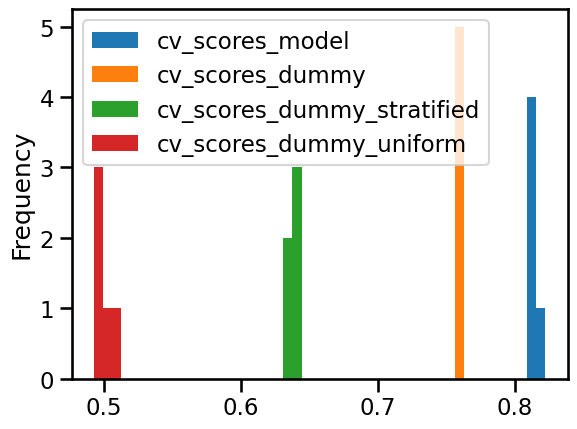

In [11]:
_ = cv_scores.plot.hist(bins=50)

-> Uniform is even worse than stratified which is worse than dummy most frequent strategy